# 02. 초기 100사이클 수명 회귀 — 1차 실행·검토 결과

2026-10-02. 어제의 설계와 추가 Q3·Q4 관측을 구현했다. 피처 A/B/C와 Dummy·Ridge·깊이 제한 RandomForest **22개 후보**를 동일한 Train 36셀의 3-fold CV(seed 42)로 비교했다. 최저 CV MAPE로 선택한 뒤 Train 36셀에 적합하고 Validation 10셀·Batch 2 39셀에 평가했다.

후보 계획·선택 기록·모델 파일·평가 기록을 저장했다. **이미 평가한 Batch 2 결과를 본 뒤 다시 튜닝하면 이번 Test는 독립적인 최종 평가로 해석할 수 없다.** 아래 실행은 저장된 결과가 있으면 그것을 읽는다. 모델 선택 기준으로 Validation/Test를 사용하지 않았지만 EDA에서 전체 Batch 1과 Batch 2 라벨 분포를 이미 관측했다는 한계가 있다.


In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.models import run_experiment
OUT = ROOT / "results/modeling"
if not (OUT / "test_evaluation.json").exists():
    run_experiment(ROOT)
else:
    print("Batch 2 재평가 없이 저장된 1차 결과를 읽습니다.")
cv = pd.read_csv(OUT / "cv_candidate_results.csv")
performance = pd.read_csv(ROOT / "results/model_performance.csv")
predictions = pd.read_csv(OUT / "cell_predictions.csv")
selected = json.loads((OUT / "selected_model.json").read_text())
ledger = json.loads((OUT / "test_evaluation.json").read_text())
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "AppleGothic" if sys.platform == "darwin" else "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
print("선택:", selected["id"], selected["features"])
print("선택시각 UTC:", selected["selected_at_utc"], "평가시각 UTC:", ledger["evaluated_at_utc"])


Batch 2 재평가 없이 저장된 1차 결과를 읽습니다.
선택: Ridge_C_policy_alpha0.1 ['q_diff_100_2', 't_max_100', 'delta_q_log_var', 'charge_c1_rate', 'charge_c2_rate', 'charge_switch_soc']
선택시각 UTC: 2026-10-02T00:06:00.112943+00:00 평가시각 UTC: 2026-10-02T00:06:00.201748+00:00


## 1. 피처 계산과 누수 방지

A는 총 용량 변화와 초기 최고온도, B는 A에 전압별 ΔQ(V) 로그 분산, C는 B에 정책의 첫 C-rate·두 번째 C-rate·전환 SOC를 추가했다. 모든 측정값은 Cycle 100 이내이며 타깃·종료 기록량은 제외했다. 원본 사이클·배열·전압 축·유한성을 확인했고 오류를 임의 보간하지 않았다.

스케일러는 Ridge Pipeline 안에서 각 CV fold의 학습 부분에서 적합했다. 최종 스케일러는 Train 36셀에서 적합했고 Validation/Test에는 적용만 했다. 분할 ID는 어제 저장한 명세를 유지했다. 데이터가 적고 정책이 양쪽에 겹치므로 새로운 정책 일반화에 대한 검증은 충분하지 않다.


In [2]:
features_b1 = pd.read_csv(OUT / "batch1_features.csv")
features_b2 = pd.read_csv(OUT / "batch2_features.csv")
for batch in ["batch1", "batch2"]:
    audit = pd.read_csv(OUT / f"{batch}_input_audit.csv")
    display(audit.groupby("status").size().rename("셀수").to_frame())
display(features_b1[["cell_id", "split"] + selected["features"]].head())
display(pd.read_csv(OUT / "cv_fold_cells.csv").groupby("cv_fold").size().rename("검증_셀수").to_frame())


,셀수
status,
passed,46


,셀수
status,
excluded_missing_label,8
passed,39


,cell_id,split,q_diff_100_2,t_max_100,delta_q_log_var,charge_c1_rate,charge_c2_rate,charge_switch_soc
0,Batch1_c00,train,0.005223,35.994705,-5.014861,3.6,3.6,80.0
1,Batch1_c01,train,0.005328,34.712265,-5.013960,3.6,3.6,80.0
2,Batch1_c02,train,0.005018,35.127342,-4.737000,3.6,3.6,80.0
3,Batch1_c03,val,0.005027,31.691414,-4.442613,4.0,4.0,80.0
4,Batch1_c04,val,0.004229,35.651741,-4.647744,4.0,4.0,80.0


,검증_셀수
cv_fold,
1,12
2,12
3,12


## 2. Train 내부 모델·피처 비교

MAPE 평균이 최소인 후보를 선택했다. 같은 seed·fold를 모든 후보에 적용했으며 fold 표준편차는 분할별 변동의 참고치다. 여러 후보를 비교한 최저 CV 점수도 선택 편향을 포함할 수 있어 새로운 배치의 성능을 보장하지 않는다.


,candidate_id,model,feature_set,parameters,CV_MAPE_mean_pct,CV_MAPE_std_pct,fold1_MAPE_pct,fold2_MAPE_pct,fold3_MAPE_pct
0,Ridge_C_policy_alpha0.1,Ridge,C_policy,"{""alpha"": 0.1}",9.8809,1.1101,11.0348,8.8205,9.7875
1,Ridge_C_policy_alpha1.0,Ridge,C_policy,"{""alpha"": 1.0}",10.1499,0.9665,10.9249,9.0669,10.4578
2,Ridge_C_policy_alpha10.0,Ridge,C_policy,"{""alpha"": 10.0}",11.5482,1.0552,12.6186,10.5089,11.5170
3,Ridge_B_voltage_alpha1.0,Ridge,B_voltage,"{""alpha"": 1.0}",12.0680,0.8251,13.0199,11.6261,11.5580
4,Ridge_B_voltage_alpha10.0,Ridge,B_voltage,"{""alpha"": 10.0}",12.0844,1.6773,13.6632,10.3235,12.2665
5,Ridge_B_voltage_alpha0.1,Ridge,B_voltage,"{""alpha"": 0.1}",12.1929,1.0535,13.2977,12.0814,11.1996
6,RF_C_policy_depth2_leaf3,RandomForest,C_policy,"{""max_depth"": 2, ""min_samples_leaf"": 3}",14.2603,3.9910,17.0463,16.0465,9.6883
7,RF_C_policy_depth3_leaf3,RandomForest,C_policy,"{""max_depth"": 3, ""min_samples_leaf"": 3}",14.2722,4.1070,17.1213,16.1308,9.5645
8,RF_B_voltage_depth3_leaf3,RandomForest,B_voltage,"{""max_depth"": 3, ""min_samples_leaf"": 3}",14.2966,4.1883,17.4140,15.9400,9.5358
9,RF_B_voltage_depth2_leaf3,RandomForest,B_voltage,"{""max_depth"": 2, ""min_samples_leaf"": 3}",14.3056,4.0136,17.1401,16.0637,9.7129


,candidate_id,CV_MAPE_mean_pct,CV_MAPE_std_pct
0,Dummy_median,20.6075,6.2081
1,Ridge_C_policy_alpha0.1,9.8809,1.1101
2,Ridge_B_voltage_alpha1.0,12.0680,0.8251
3,Ridge_A_summary_alpha10.0,16.8665,1.4063


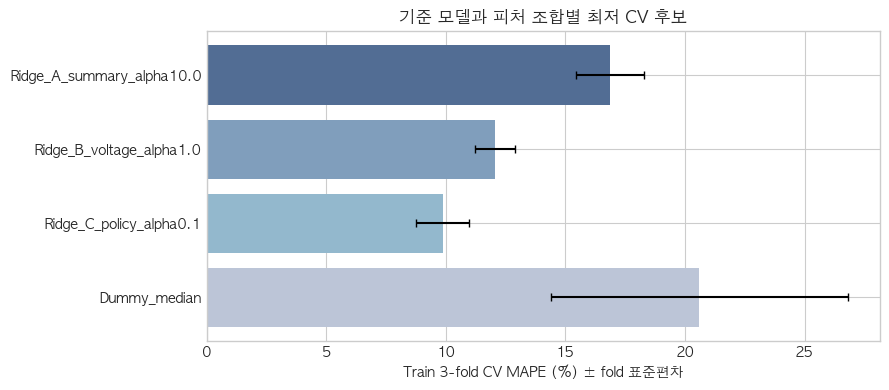

In [3]:
display(cv.round(4))
best = cv.sort_values("CV_MAPE_mean_pct").groupby("feature_set", sort=False).head(1)
dummy = cv[cv.model == "Dummy"]
comparison = pd.concat([dummy, best], ignore_index=True).drop_duplicates("candidate_id")
display(comparison[["candidate_id", "CV_MAPE_mean_pct", "CV_MAPE_std_pct"]].round(4))
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(comparison.candidate_id, comparison.CV_MAPE_mean_pct, xerr=comparison.CV_MAPE_std_pct,
        color=["#bcc5d7", "#93b8cd", "#809ebc", "#526d94"][:len(comparison)], capsize=3)
ax.set(xlabel="Train 3-fold CV MAPE (%) ± fold 표준편차", title="기준 모델과 피처 조합별 최저 CV 후보")
fig.tight_layout()
fig.savefig(OUT / "cv_feature_comparison.png", dpi=160)
plt.show()


## 3. 고정 모델의 Validation·Batch 2 평가

Train은 최종 모델의 학습셋 재예측이 아니라 선택된 후보의 out-of-fold 예측으로 계산했다. 최종 모델은 Train 36셀로만 적합했다. 각 지표의 정의와 모델 학습 표본은 동일하게 유지했다. MAE·RMSE는 사이클 단위다.


,split,n_cells,MAPE_pct,MAE_cycles,RMSE_cycles,candidate_id
0,Train_CV,36,9.8809,78.6283,98.4455,Ridge_C_policy_alpha0.1
1,Valid,10,8.9327,84.6698,103.6344,Ridge_C_policy_alpha0.1
2,Test_Batch2,39,58.7329,274.0386,313.6859,Ridge_C_policy_alpha0.1


,gap,gap_percentage_points
0,Valid_minus_TrainCV,-0.9482
1,Test_minus_Valid,49.8002
2,Test_minus_9.1,49.6329


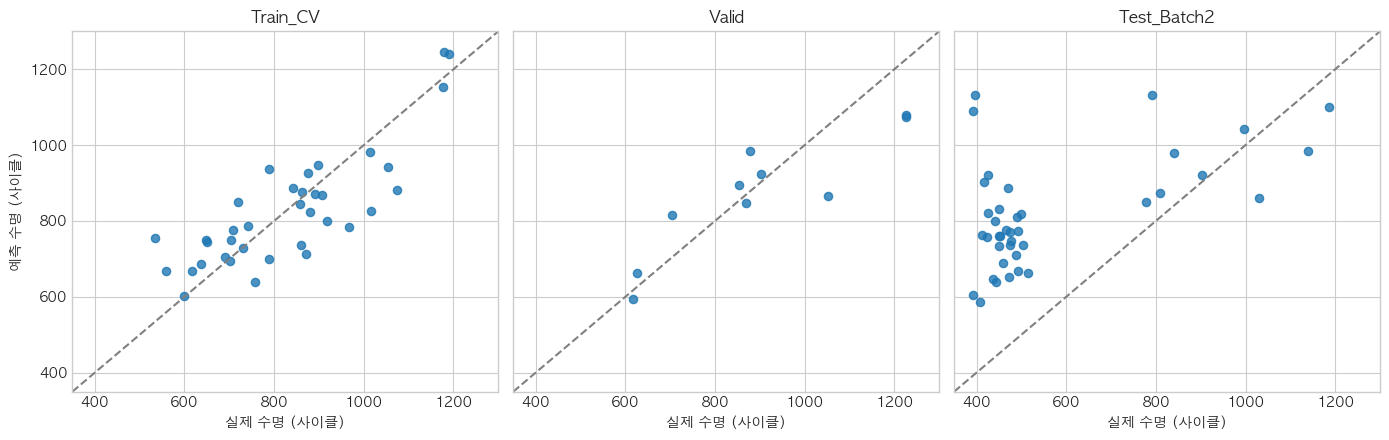

In [4]:
display(performance.round(4))
display(pd.read_csv(OUT / "performance_gaps.csv").round(4))
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharex=True, sharey=True)
for ax, role in zip(axes, ["Train_CV", "Valid", "Test_Batch2"]):
    part = predictions[predictions.split == role]
    ax.scatter(part.cycle_life, part.prediction, s=35, alpha=.8)
    ax.plot([350, 1300], [350, 1300], linestyle="--", color="gray")
    ax.set(title=role, xlabel="실제 수명 (사이클)", xlim=(350, 1300), ylim=(350, 1300))
axes[0].set_ylabel("예측 수명 (사이클)")
fig.tight_layout()
fig.savefig(OUT / "actual_vs_prediction.png", dpi=160)
plt.show()


## 4. Batch 2 오차와 학습 범위 차이

Test 결과를 본 뒤 모델을 다시 선택하지 않았다. 아래는 실패를 설명하기 위한 사후 분석이다. 입력별 최솟값·최댓값 비교는 범위 밖 관측을 찾는 기초 점검이며 분포 변화의 원인을 입증하지 않는다. 범위 안에서도 변수의 결합·정책 조건이 다를 수 있다.


In [5]:
test = predictions[predictions.split == "Test_Batch2"].copy()
test["newstructure"] = test.policy.str.contains("newstructure", regex=False)
policy_errors = test.groupby("policy").agg(셀수=("cell_id", "size"), 실제수명평균=("cycle_life", "mean"),
    예측수명평균=("prediction", "mean"), MAPE_pct=("APE_pct", "mean"), 평균오차_cycles=("error_cycles", "mean"))
policy_errors.to_csv(OUT / "batch2_policy_errors.csv")
display(policy_errors.round(3))
group_errors = test.groupby("newstructure").agg(셀수=("cell_id", "size"), MAPE_pct=("APE_pct", "mean"),
    평균오차_cycles=("error_cycles", "mean"))
group_errors.to_csv(OUT / "batch2_structure_errors.csv")
display(group_errors.round(3))
display(test.nlargest(5, "APE_pct").round(3))
train = features_b1[features_b1.split == "train"]
ranges = []
for col in selected["features"]:
    low, high = train[col].min(), train[col].max()
    ranges.append({"feature": col, "Train_min": low, "Train_max": high,
        "Test_min": features_b2[col].min(), "Test_max": features_b2[col].max(),
        "Test_outside_train_range": int(((features_b2[col] < low) | (features_b2[col] > high)).sum())})
ranges = pd.DataFrame(ranges)
ranges.to_csv(OUT / "feature_range_audit.csv", index=False)
display(ranges.round(5))


,셀수,실제수명평균,예측수명평균,MAPE_pct,평균오차_cycles
policy,,,,,
3.6C(30%)-6C,2,421.000,911.836,116.593,490.836
3.6C(9%)-5C,2,394.500,1110.729,181.537,716.229
4.65C(44%)-5C,2,482.500,797.671,65.365,315.171
4.65C(69%)-6C,2,452.000,664.557,46.972,212.557
4.8C(80%)-4.8C,5,483.600,673.313,39.476,189.713
4.8C(80%)-4.8C-newstructure,3,871.667,860.998,11.151,-10.668
5.2C(50%)-4.25C,5,454.000,766.136,69.075,312.136
5.2C(58%)-4C,4,477.750,747.453,56.674,269.703
5.2C(58%)-4C-newstructure,3,961.667,961.876,10.752,0.210


,셀수,MAPE_pct,평균오차_cycles
newstructure,,,
False,30,72.338,319.988
True,9,13.384,29.913


,batch,cell_id,policy,cycle_life,split,prediction,error_cycles,APE_pct,newstructure
61,Batch2,Batch2_c15,3.6C(9%)-5C,396.0,Test_Batch2,1132.628,736.628,186.017,False
52,Batch2,Batch2_c06,3.6C(9%)-5C,393.0,Test_Batch2,1088.830,695.830,177.056,False
51,Batch2,Batch2_c05,3.6C(30%)-6C,416.0,Test_Batch2,902.705,486.705,116.996,False
60,Batch2,Batch2_c14,3.6C(30%)-6C,426.0,Test_Batch2,920.967,494.967,116.189,False
75,Batch2,Batch2_c31,5.6C(26%)-4.5C,425.0,Test_Batch2,821.565,396.565,93.309,False


,feature,Train_min,Train_max,Test_min,Test_max,Test_outside_train_range
0,q_diff_100_2,-0.01138,0.00663,-0.02291,0.01278,12
1,t_max_100,31.65890,38.72872,31.86726,40.46694,8
2,delta_q_log_var,-5.01486,-3.35034,-4.44859,-3.08588,11
3,charge_c1_rate,3.60000,8.00000,3.60000,6.00000,0
4,charge_c2_rate,3.00000,5.40000,3.00000,6.00000,4
5,charge_switch_soc,15.00000,80.00000,9.00000,80.00000,2


## 5. 1차 결과와 함께 검토할 점

- Train CV **9.88%**, Validation **8.93%**, Batch 2 **58.73%** MAPE다. Validation이 목표 9.1%보다 낮아도 최종 Test 목표를 달성한 것은 아니다. 목표 대비 Test Gap은 **+49.63%p**다.
- A 요약 피처 최저 CV **16.87%**, B 전압 피처 추가 **12.07%**, C 정책 변수 추가 **9.88%**로 내부 점수는 개선됐다. 고정된 3-fold와 작은 표본에서의 비교이며 외부 배치 개선을 입증하지 않는다.
- Batch 2 일반 표기 30셀은 MAPE **72.34%**, newstructure 9셀은 **13.38%**다. 일반 표기 셀을 평균 약 **320사이클 과대예측**했다. 예를 들어 `Batch2_c15` 실제 396사이클을 약 1,133사이클로 예측했다.
- 학습 수명 최저는 534사이클이며 Batch 2의 짧은 수명 영역은 학습에서 충분히 관측되지 않았다. 용량 변화는 12셀, 최고온도는 8셀, 로그 분산은 11셀에서 Train 범위를 벗어났다. 단순 피처 범위 검사만으로 오차 원인을 확정하지 않는다.
- 어제 확인한 정책·배치 차이와 일반화 한계가 실제 성능에서도 나타났다. 지금 결과를 근거로 테스트 셀을 제외하거나 같은 Test로 재튜닝하지 않는다.

**다음 공동 검토:** 계산·분할·점수 정의가 타당한지 먼저 확인한다. 개선 실험은 정책 일반화 검증과 추가 데이터/실험 조건 확인을 우선 고려하며, Batch 2를 이미 관측한 후속 탐색임을 명시한다. 이번 고정 모델과 평가 결과는 기준 기록으로 보존한다.
